##  ***Iris Data Analytics Project**



---
---



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris(as_frame=True)
df_iris = iris.frame

# Rename the target column to 'species' to match subsequent code in the classification cell
df_iris = df_iris.rename(columns={'target': 'species'})

# Save the DataFrame to a CSV file in the content directory
df_iris.to_csv('/content/iris.csv', index=False)

print("Iris dataset loaded and saved as /content/iris.csv")

Iris dataset loaded and saved as /content/iris.csv


Now that the `iris.csv` is prepared and saved, let's load it into our main DataFrame `df`.

In [6]:
import os
os.listdir('/content')

['.config', 'sample_data']

In [29]:
import pandas as pd

df = pd.read_csv('/content/iris.csv')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
# Check missing values
df.isnull().sum()

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Standardize column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

df.head()

/tmp/ipykernel_8289/2659800871.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [10]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


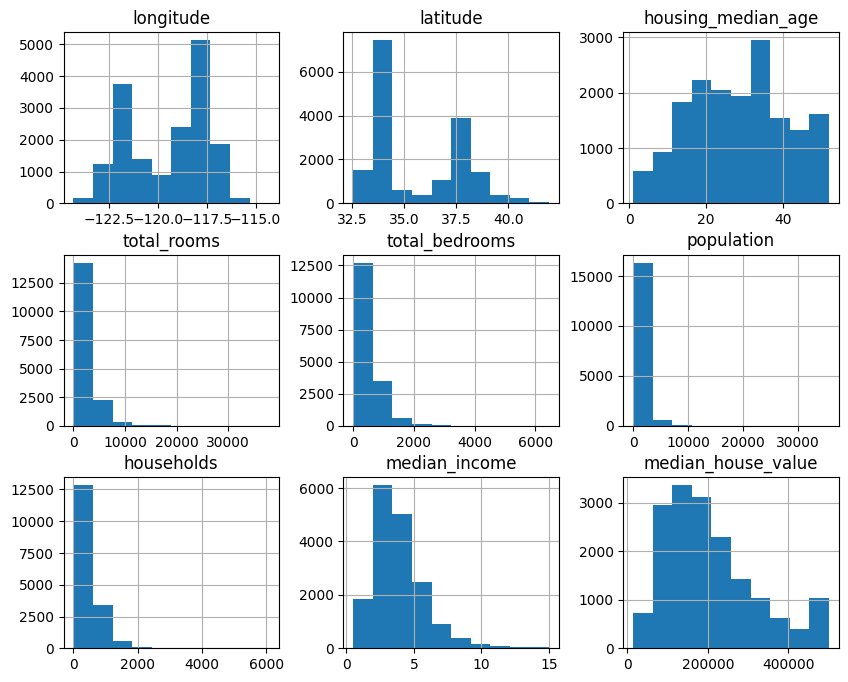

In [17]:
df.hist(figsize=(10,8))
plt.show()

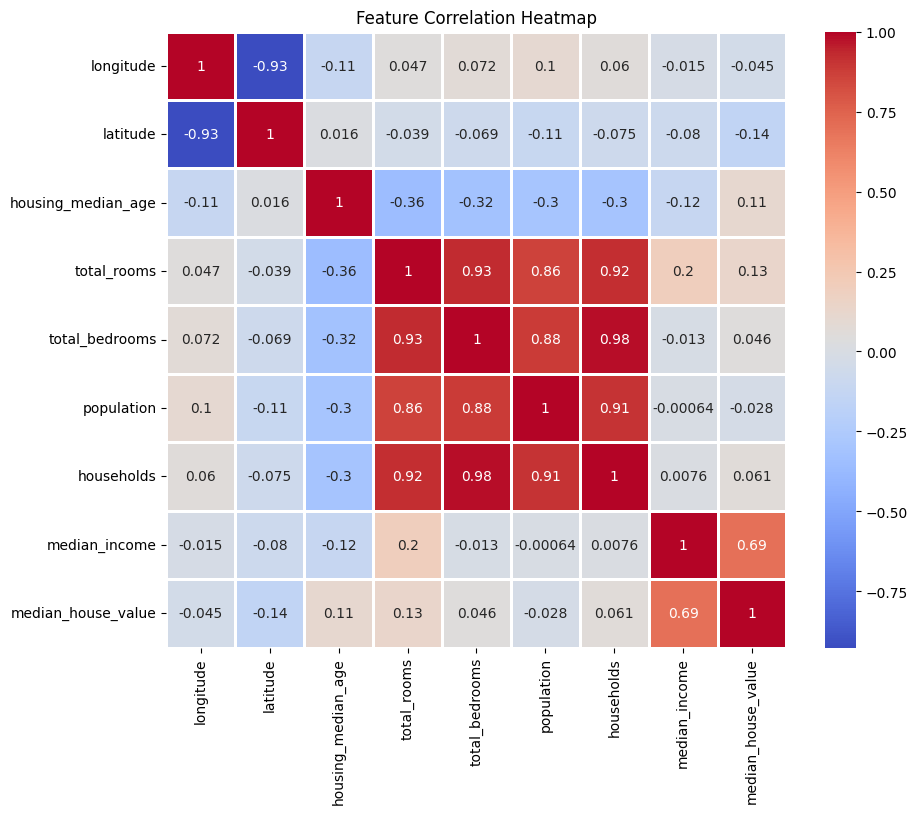

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

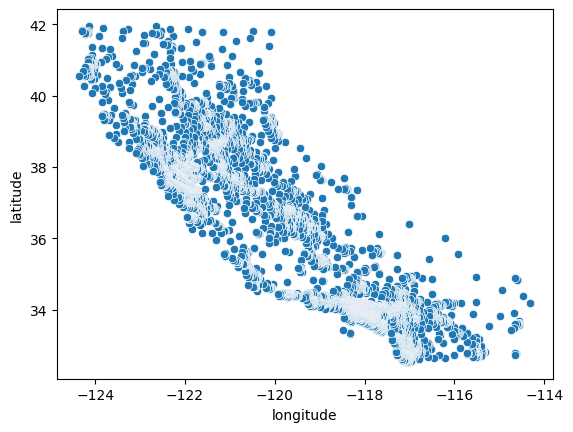

In [13]:
sns.scatterplot(x=df.columns[0], y=df.columns[1], data=df)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features & target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

LinearRegression()

In [18]:
print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model Coefficients: [-4.37315895e+04 -4.36782012e+04  1.16730361e+03 -8.07684657e+00
  1.16999107e+02 -3.70076432e+01  4.16054563e+01  4.04963941e+04]
Intercept: -3665399.402812804


In [24]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [25]:
import numpy as np

y_test = np.array(y_test)
y_pred = np.array(y_pred)

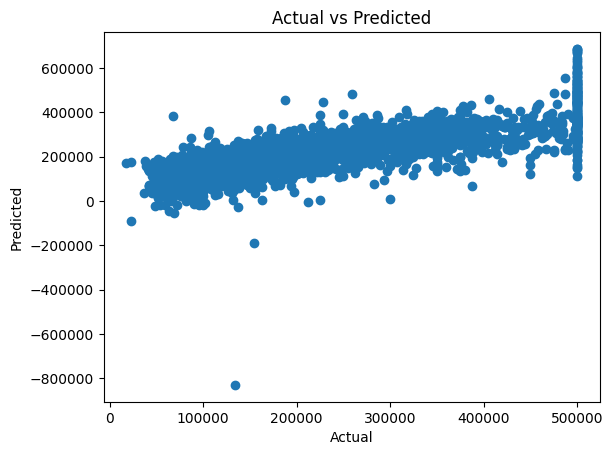

In [26]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

##  Classification Model using Logistic Regression

Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.82      0.90        11
           2       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.94      0.93      0.93        30



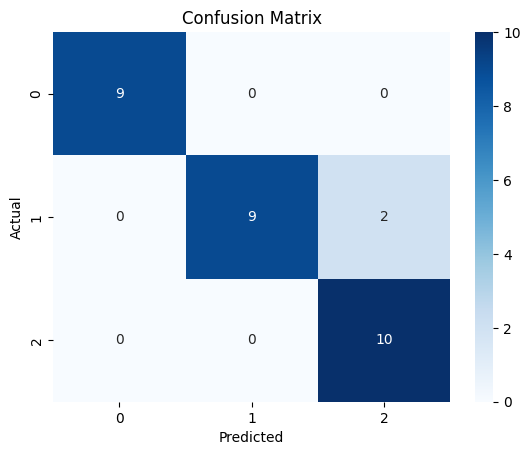

In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert categorical to numeric
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

# Split data
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LogisticRegression(max_iter=200) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

IRIS DATA ANALYTICS PROJECT

---



## Problem Statement
This project analyzes the Iris dataset to understand patterns and build a predictive model

# Steps Performed
- Data Loading
- Data Cleaning
- EDA
- Model Building

# Observations
- Petal features are highly important
- Setosa is easily separable

## Conclusion
This project demonstrates data analysis and predictive modeling skills.



- Data was successfully cleaned and analyzed  
- EDA revealed strong relationships between petal features  
- Logistic Regression achieved high accuracy in classification  
- This project demonstrates end-to-end data analysis and machine learning workflow